In [1]:
import os
import numpy as np
import copy

import matplotlib as mpl
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt

import numpy as np
from scipy.integrate import quad
from scipy.interpolate import make_interp_spline
from numpy.polynomial import polynomial

In [2]:
from icecube.icetray import OMKey
from icecube.dataclasses import ModuleKey
from icecube import dataio, dataclasses, simclasses

In [3]:
%env PONESRCDIR '/home/users/fhenningsen/pone_offline'
from WaterOpticalModel import MakePoneMediumPropertiesConservativeExtendedRange as Medium
from Utilities import DOMUtility

env: PONESRCDIR='/home/users/fhenningsen/pone_offline'


/home/users/fhenningsen/pone_offline/Flasher/examples/Utilities/DOMUtility.py:10: UserWarning: 
This call to matplotlib.use() has no effect because the backend has already
been chosen; matplotlib.use() must be called *before* pylab, matplotlib.pyplot,
or matplotlib.backends is imported for the first time.

The backend was *originally* set to 'module://ipykernel.pylab.backend_inline' by the following code:
  File "/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/runpy.py", line 193, in _run_module_as_main
    "__main__", mod_spec)
  File "/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/runpy.py", line 85, in _run_code
    exec(code, run_globals)
  File "/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/trait

## Check GCD

In [4]:
#Using new GCD:
geometry = dataio.I3File('/home/users/fhenningsen/pone_offline/GCD/PONE_Phase1.i3.gz')

gframe = geometry.pop_frame()  
geo = gframe["I3Geometry"] #access geo file via key
all_dom_keys = geo.omgeo.keys()

print(all_dom_keys[:5])
print('...')
print(all_dom_keys[-5:])

[OMKey(1,1,1), OMKey(1,1,2), OMKey(1,1,3), OMKey(1,1,4), OMKey(1,1,5)]
...
[OMKey(10,20,12), OMKey(10,20,13), OMKey(10,20,14), OMKey(10,20,15), OMKey(10,20,16)]


In [5]:
for i in all_dom_keys[::1970]:
    print(i, geo.omgeo[i])

OMKey(1,1,1) [I3OMGeo Position: I3Position(12.5,-21.6506,-450)
      Orientation: I3Orientation: 
    Dir: (0,0,-1)
     Up: (1,0,0)
  Right: (0,-1,0)
           OMType: 130
             Area: 0.585754 ]
OMKey(7,4,3) [I3OMGeo Position: I3Position(-12.5,21.6506,-300)
      Orientation: I3Orientation: 
    Dir: (0,0,-1)
     Up: (1,0,0)
  Right: (0,-1,0)
           OMType: 130
             Area: 0.585754 ]


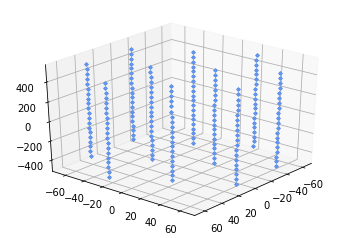

In [6]:
fig = plt.figure()
ax = plt.axes(projection='3d')

for i in all_dom_keys:
    om = geo.omgeo[i]
    x, y, z = om.position[0], om.position[1], om.position[2]
    ax.scatter(x, y, z, color='cornflowerblue', s=5)
    ax.view_init(30, 40)

## Check optical properties

In [7]:
m = Medium.MakePoneMediumProperties()

In [8]:
# from WaterOpticalModule/MakePoneMediumPropertiesConservativeExtendedRange.py
# https://github.com/pone-software/pone_offline/blob/608423314880fe96e9bebf191923a9dd111aefa6/WaterOpticalModel/MakePoneMediumPropertiesConservativeExtendedRange.py
absLenTable = [ 0.800,   1.629,   2.457,   3.286,   4.114,   4.943,   5.771,   6.600,   7.429,
                8.257,   9.086,  10.214,  11.643,  13.071,  14.500,  17.520,  20.540,  23.560,
               26.580,  29.600,  27.911,  26.222,  24.533,  22.844,  21.156,  19.467,  17.778,
               16.089,  14.400,  12.711,  11.022,   9.333,   7.644,   6.563,   6.089,   5.615,
                5.141,   4.667,   4.193,   3.720,   3.246,   2.772,   2.298,   1.824,   1.350,
                0.876]
wls = np.linspace(m.GetMinWavelength(), m.GetMaxWavelength(), len(absLenTable)) * 1e9

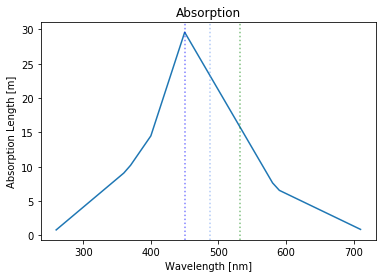

In [9]:
plt.figure()
plt.plot(wls, absLenTable)
plt.axvline(450, ls=':', alpha=0.5, color='blue')
plt.axvline(488, ls=':', alpha=0.5, color='cornflowerblue')
plt.axvline(532, ls=':', alpha=0.5, color='green')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Absorption Length [m]')
plt.title('Absorption')
plt.show()

In [10]:
# from WaterOpticalModule/MakePoneMediumPropertiesConservativeExtendedRange.py
# https://github.com/pone-software/pone_offline/blob/608423314880fe96e9bebf191923a9dd111aefa6/WaterOpticalModel/MakePoneMediumPropertiesConservativeExtendedRange.py

# petzold scattering angle distribution
deg = np.pi/180.

petzold_powerLawIndexBeforeFirstBin = -1.346
petzold_data_ang = [1e-9,
                    0.100*deg,   0.126*deg,   0.158*deg,   0.200*deg,   0.251*deg,
                    0.316*deg,   0.398*deg,   0.501*deg,   0.631*deg,   0.794*deg,
                    1.000*deg,   1.259*deg,   1.585*deg,   1.995*deg,   2.512*deg,
                    3.162*deg,   3.981*deg,   5.012*deg,   6.310*deg,   7.943*deg,
                    10.000*deg,  15.000*deg,  20.000*deg,  25.000*deg,  30.000*deg,
                    35.000*deg,  40.000*deg,  45.000*deg,  50.000*deg,  55.000*deg,
                    60.000*deg,  65.000*deg,  70.000*deg,  75.000*deg,  80.000*deg,
                    85.000*deg,  90.000*deg,  95.000*deg, 100.000*deg, 105.000*deg,
                    110.000*deg, 115.000*deg, 120.000*deg, 125.000*deg, 130.000*deg,
                    135.000*deg, 140.000*deg, 145.000*deg, 150.000*deg, 155.000*deg,
                    160.000*deg, 165.000*deg, 170.000*deg, 175.000*deg, 180.000*deg]
petzold_data_val=[0.,  # <- this 0 will be replaced right after the definition
                  1.767e+03, 1.296e+03, 9.502e+02, 6.991e+02, 5.140e+02,
                  3.764e+02, 2.763e+02, 2.188e+02, 1.444e+02, 1.022e+02,
                  7.161e+01, 4.958e+01, 3.395e+01, 2.281e+01, 1.516e+01,
                  1.002e+01, 6.580e+00, 4.295e+00, 2.807e+00, 1.819e+00,
                  1.153e+00, 4.893e-01, 2.444e-01, 1.472e-01, 8.609e-02,
                  5.931e-02, 4.210e-02, 3.067e-02, 2.275e-02, 1.699e-02,
                  1.313e-02, 1.046e-02, 8.488e-03, 6.976e-03, 5.842e-03,
                  4.953e-03, 4.292e-03, 3.782e-03, 3.404e-03, 3.116e-03,
                  2.912e-03, 2.797e-03, 2.686e-03, 2.571e-03, 2.476e-03,
                  2.377e-03, 2.329e-03, 2.313e-03, 2.365e-03, 2.506e-03,
                  2.662e-03, 2.835e-03, 3.031e-03, 3.092e-03, 3.154e-03]
# power law for values below bin 1
petzold_data_val[0] = 2.*np.pi*np.sin(petzold_data_ang[1])*petzold_data_val[1] * \
                       ((petzold_data_ang[0]/petzold_data_ang[1])**petzold_powerLawIndexBeforeFirstBin)

for i in range(len(petzold_data_val)):
    petzold_data_val[i] = 2.*np.pi*petzold_data_val[i]*np.sin(petzold_data_ang[i])

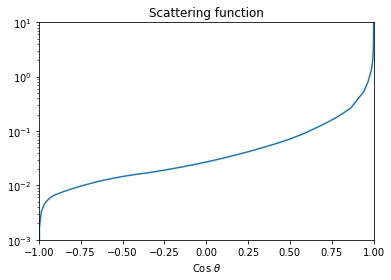

In [11]:
plt.figure()
plt.plot(np.cos(petzold_data_ang), petzold_data_val)
plt.yscale('log')
plt.xlim(-1, 1)
plt.ylim(1e-3, 1e1)
plt.xlabel('Cos $\\theta$')
plt.title('Scattering function')
plt.show()

## Check the data

In [57]:
f = dataio.I3File('/home/users/fhenningsen/pone_offline/Flasher/examples/test-isotropic.i3.bz2')

In [58]:
frame = f.pop_daq()

In [59]:
frame.keys()

['SPEAbove',
 'SPEScalingFactors',
 'I3EventHeader',
 'I3Photons',
 'MCTimeIncEventID',
 'BadDomsListSLC',
 'FlasherPulseSeries',
 'BadDomsList',
 'I3DetectorStatus',
 'Subdetectors',
 'I3ModuleGeoMap',
 'StartTime',
 'I3OMGeoMap',
 'EndTime',
 'I3Calibration',
 'I3Geometry']

In [60]:
print(frame['I3EventHeader'])

[ I3EventHeader:
        StartTime: 2012-01-10 05:20:50.961,584,445,8 UTC
         EndTime : 1905-06-04 18:35:44.000,000,000,0 UTC
           RunID : 1
        SubrunID : 0
         EventID : 1
      SubEventID : 0
  SubEventStream : 
]


In [61]:
ph = frame['I3Photons']

In [62]:
for i in ph.iteritems():
    print(i[0], len(i[1]), i[1][0].time, type(i[0]))

ModuleKey(1,9) 4 335.21661376953125 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(1,10) 16 238.5732879638672 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(1,11) 3 335.46624755859375 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(1,12) 1 524.2837524414062 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(3,10) 1 418.2257080078125 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(4,9) 1 340.02862548828125 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(4,10) 20 252.11822509765625 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(4,11) 6 331.3912658691406 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(5,8) 2 468.40264892578125 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(5,9) 2216 232.80172729492188 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(5,10) 36518 5.964849472045898 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(5,11) 2429 240.7306365966797 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(5,12) 4 470.4391174316406 <class 'icecube.dataclasses.ModuleKey'

In [63]:
photon = i[1][0]

In [64]:
print(photon)

[I3CompressedPhoton: 
        Time: 333.476
      Weight: 1
  Wavelength: 4.02282e-07
      Zenith: 2.3566
     Azimuth: 5.23277
    Position: (0.197418,-0.0212517,-0.0760918)
  Group Vel.: 0.214994
  ParticleID: 0,0)]


In [65]:
# ceate a general event dictionary with 2D array (charge,time) as values
event = {} 
for i in all_dom_keys:
    key = ModuleKey(i[0], i[1])
    event[key] = [0,[],[]]
    
# as a first step we create a new empty data dictioniary:
data_dict=copy.deepcopy(event)

# then we read in the i3 file and iterate n frames
n = 1
for i in range(n):
    data_tmp_fr = f.pop_daq() # pop photon frame
    data_tmp_k = data_tmp_fr['I3Photons'] # get photon objects
    
    for c,j in enumerate(data_tmp_k.iteritems()): 
        dom_key = ModuleKey(j[0][0], j[0][1])
        hits = len(j[1])
        data_dict[dom_key][0] += hits # add up charge
        data_dict[dom_key][1] += [j.time for j in j[1]] # record arrival times   
        
# and find average over all frames
for i in all_dom_keys:
    dom_key = ModuleKey(i[0], i[1])
    data_dict[dom_key][0] = data_dict[dom_key][0]/float(n)
        
    if data_dict[dom_key][0] > 0: # look only at hit DOMs
        bins = np.linspace(0, 10000, 1001) # bin array in 10ns
        data_dict[dom_key][2] = np.mean(data_dict[dom_key][1]) # averaging time array to mean arrival time
        
    else: # set mean arrival time to 0 for non hit DOMs
        if i[2] == 16:
            data_dict[dom_key][2] = [0]

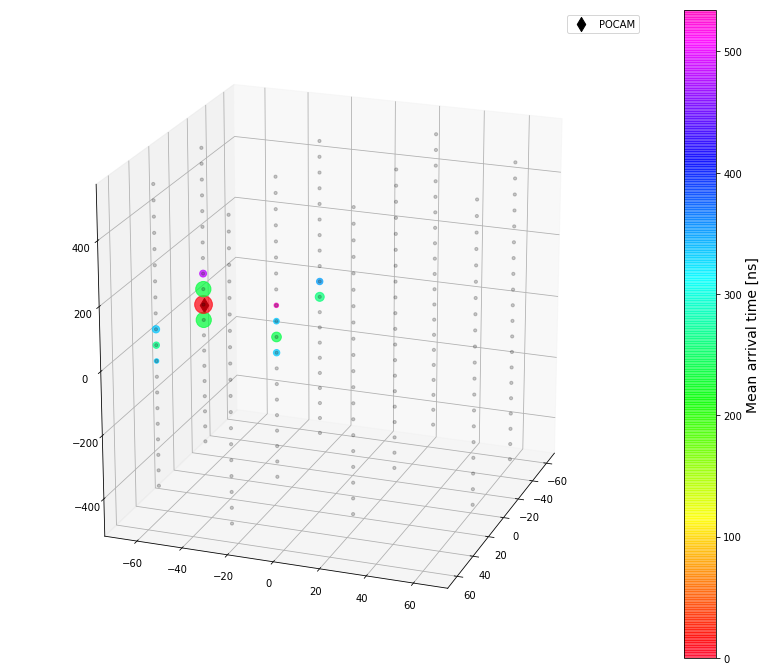

In [66]:
### Then plot ###
pocam_key=OMKey(5, 10, 1)

fig = plt.figure(figsize=(11,9))
ax = Axes3D(fig)

#DOM arrays for plotting DOMs as black dots
x_doms_d=[]
y_doms_d=[]
z_doms_d=[]
#DOM arrays for plotting hit DOMs 
x_doms=[]
y_doms=[]
z_doms=[]
times=[]
sizes=[]

for key in event.keys():
    i = OMKey(key[0], key[1], 1)
    x_doms_d.append(geo.omgeo[i].position.x)
    y_doms_d.append(geo.omgeo[i].position.y)
    z_doms_d.append(geo.omgeo[i].position.z)

    if data_dict[key][0] != 0: # only look at hit DOMs and ignore upgrade modules (+distance limit)
        x_doms.append(geo.omgeo[i].position.x)
        y_doms.append(geo.omgeo[i].position.y)
        z_doms.append(geo.omgeo[i].position.z)
        times.append(data_dict[key][2]) # time as color
        sizes.append(30*np.log(data_dict[key][0] + 1)) # counts as size (scaling is arbitrary in this case)

# detector
p = ax.scatter(x_doms_d, y_doms_d, z_doms_d, c='k', s=10, alpha=0.2)

# hits
p = ax.scatter(x_doms, y_doms, z_doms, c=times, cmap='gist_rainbow', vmin=0, vmax=np.max(times), s=sizes, alpha=0.7)
cbar = fig.colorbar(p)
cbar.set_label("Mean arrival time [ns]", fontsize=14)

# flasher
p = ax.scatter(geo.omgeo[pocam_key].position.x,
               geo.omgeo[pocam_key].position.y,
               geo.omgeo[pocam_key].position.z,
               s=100, c='k', marker='d', label='POCAM',
               zorder=0)

ax.view_init(20, 20)
ax.legend(loc="upper right")
plt.show()

In [67]:
for key in data_dict:
    q = data_dict[key][0]
    if q > 10:
        print(key, q)

ModuleKey(1,10) 22.0
ModuleKey(5,9) 2202.0
ModuleKey(5,10) 36116.0
ModuleKey(5,11) 2376.0
ModuleKey(6,10) 14.0


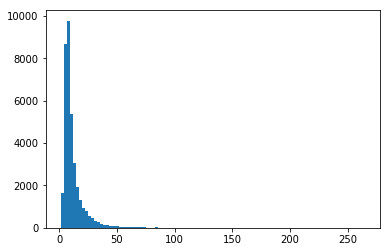

In [68]:
plt.figure()
plt.hist(data_dict[ModuleKey(5,10)][1], bins=100)
# plt.yscale('log')
plt.show()